## Imports and Setup

In [1]:
import warnings
import os
import sys
sys.path.append('..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import json
import time

from src import (
    NeuralThompson,
    FeaturePipeline,
    TREATMENTS, N_TREATMENTS, IDX_TO_TREATMENT, TREATMENT_TO_IDX,
    seed_everything, setup_plotting, timer,
    TREATMENT_COLORS,
)
from src.data_generator import reward_oracle, generate_patient
from src.explainability import (
    ExplainabilityExtractor,
    check_contraindications,
    check_warnings,
    run_safety_checks,
    get_safety_for_recommended,
    check_fairness,
)

warnings.filterwarnings("ignore", category=UserWarning, module="sklearn")

seed_everything(42)
setup_plotting()
print("Setup complete ✓")

2026-04-16 06:04:51.250 | INFO     | src.utils:seed_everything:436 - Seeds set to 42


Setup complete ✓


## Load Pipeline and Model

In [2]:
print("Loading pipeline...")
pipe_scaled = FeaturePipeline.load("../models/feature_pipeline_scaled.joblib")
input_dim = len(pipe_scaled.features)
print(f"Input dim: {input_dim}")

print("Loading NeuralThompson...")
model = NeuralThompson(input_dim=input_dim, hidden_dims=[128, 64], noise_variance=0.25)
model.load("../models/neural_thompson.pt")
model.reset_posterior()  # reset posterior to prior for fresh exploration
print("NeuralThompson ready ✓")

2026-04-16 06:04:51.321 | INFO     | src.feature_engineering:load:310 - FeaturePipeline loaded from ../models/feature_pipeline_scaled.joblib: 25 features, scale=True


Loading pipeline...
Input dim: 25
Loading NeuralThompson...


2026-04-16 06:04:52.335 | INFO     | src.neural_bandit:__init__:158 - NeuralThompson initialized: input=25, hidden=[128, 64], device=cpu
2026-04-16 06:04:52.347 | INFO     | src.neural_bandit:load:1000 - Loaded NeuralThompson (with posterior) from ../models/neural_thompson.pt


NeuralThompson ready ✓


## Define Per-Step Extraction Function

In [3]:
## This is the core function. For a single patient, it extracts
## EVERY value the frontend could possibly need.

CONTEXT_FEATURES = [
    "age", "bmi", "hba1c_baseline", "egfr", "diabetes_duration",
    "fasting_glucose", "c_peptide", "cvd", "ckd", "nafld",
    "hypertension", "bp_systolic", "ldl", "hdl", "triglycerides", "alt",
]

def extract_step(
    patient_context: dict,
    model: NeuralThompson,
    pipeline: FeaturePipeline,
    step_number: int,
    epsilon: float,
) -> dict:
    """
    Extract the full payload for one simulation step.

    Returns a dict containing everything the frontend needs
    for this single patient decision.
    """

    # ── 1. Transform patient features ──
    x = pipeline.transform_single(patient_context)

    # ── 2. Oracle ground truth ──
    oracle_rewards = {
        t: reward_oracle(patient_context, t, noise=False)
        for t in TREATMENTS
    }
    oracle_rewards_list = [oracle_rewards[t] for t in TREATMENTS]
    optimal_idx = int(np.argmax(oracle_rewards_list))
    optimal_treatment = TREATMENTS[optimal_idx]
    optimal_reward = oracle_rewards_list[optimal_idx]

    # ── 3. Model decision via Thompson Sampling ──
    selected_idx, sampled_values = model.select_action(x)
    selected_treatment = IDX_TO_TREATMENT[selected_idx]

    # ── 4. Posterior means and confidence ──
    confidence = model.compute_confidence(x, n_draws=200)

    # ── 4b. Find actual runner-up (second highest win rate) ──
    sorted_by_winrate = sorted(
        confidence["win_rates"].items(), key=lambda t: t[1], reverse=True
    )
    runner_up_treatment = sorted_by_winrate[1][0]
    runner_up_winrate = sorted_by_winrate[1][1]

    # ── 5. Exploration vs exploitation ──
    posterior_mean_best = max(confidence["posterior_means"], key=confidence["posterior_means"].get)
    explored = selected_treatment != posterior_mean_best

    # Also support epsilon-greedy style exploration
    epsilon_explored = np.random.random() < epsilon

    # ── 6. Observed reward (with noise) ──
    observed_reward = reward_oracle(patient_context, selected_treatment, noise=True)
    instantaneous_regret = optimal_reward - reward_oracle(patient_context, selected_treatment, noise=False)
    matched_oracle = selected_idx == optimal_idx

    # ── 7. Safety checks ──
    safety_all = run_safety_checks(patient_context)
    safety_for_selected = get_safety_for_recommended(safety_all, selected_treatment)

    # ── 8. Build the full payload ──
    payload = {
        # Step metadata
        "step": step_number,
        "epsilon": round(epsilon, 6),

        # Patient context (raw features)
        "patient": {feat: patient_context[feat] for feat in CONTEXT_FEATURES},

        # Oracle ground truth
        "oracle": {
            "rewards": {t: round(r, 4) for t, r in oracle_rewards.items()},
            "optimal_treatment": optimal_treatment,
            "optimal_idx": optimal_idx,
            "optimal_reward": round(optimal_reward, 4),
        },

        # Model decision
        "decision": {
            "selected_treatment": selected_treatment,
            "selected_idx": selected_idx,
            "sampled_values": {
                IDX_TO_TREATMENT[i]: round(float(sampled_values[i]), 4)
                for i in range(N_TREATMENTS)
            },
            "posterior_means": confidence["posterior_means"],
            "win_rates": confidence["win_rates"],
            "confidence_pct": confidence["confidence_pct"],
            "confidence_label": confidence["confidence_label"],
            "runner_up": runner_up_treatment,
            "runner_up_winrate": round(runner_up_winrate, 3),
            "mean_gap": confidence["mean_gap"],
        },

        # Exploration metadata
        "exploration": {
            "thompson_explored": explored,
            "epsilon_explored": epsilon_explored,
            "posterior_mean_best": posterior_mean_best,
        },

        # Outcome
        "outcome": {
            "observed_reward": round(observed_reward, 4),
            "instantaneous_regret": round(instantaneous_regret, 4),
            "matched_oracle": matched_oracle,
        },

        # Safety
        "safety": {
            "status": safety_for_selected["status"],
            "contraindications": safety_for_selected["recommended_contraindications"],
            "warnings": safety_for_selected["recommended_warnings"],
            "excluded_treatments": {
                t: reasons for t, reasons in safety_for_selected["excluded_treatments"].items()
            },
        },
    }

    return payload


# Quick test on one patient
test_patient = generate_patient(np.random.RandomState(0))
test_payload = extract_step(test_patient, model, pipe_scaled, step_number=1, epsilon=0.3)

print("Payload keys:", list(test_payload.keys()))
print(f"\nPatient age: {test_payload['patient']['age']}, BMI: {test_payload['patient']['bmi']}")
print(f"Oracle optimal: {test_payload['oracle']['optimal_treatment']} (reward: {test_payload['oracle']['optimal_reward']})")
print(f"Model selected: {test_payload['decision']['selected_treatment']}")
print(f"Confidence: {test_payload['decision']['confidence_pct']}% ({test_payload['decision']['confidence_label']})")
print(f"Runner-up: {test_payload['decision']['runner_up']} (winrate: {test_payload['decision']['runner_up_winrate']})")
print(f"Observed reward: {test_payload['outcome']['observed_reward']}")
print(f"Regret: {test_payload['outcome']['instantaneous_regret']}")
print(f"Matched oracle: {test_payload['outcome']['matched_oracle']}")
print(f"Safety: {test_payload['safety']['status']}")
print(f"\nOracle rewards: {test_payload['oracle']['rewards']}")
print(f"Posterior means: {test_payload['decision']['posterior_means']}")
print(f"Win rates: {test_payload['decision']['win_rates']}")
print(f"\n✓ Single step extraction working")

Payload keys: ['step', 'epsilon', 'patient', 'oracle', 'decision', 'exploration', 'outcome', 'safety']

Patient age: 79, BMI: 37.6
Oracle optimal: DPP-4 (reward: 1.0686)
Model selected: SGLT-2
Confidence: 26% (LOW)
Runner-up: Insulin (winrate: 0.22)
Observed reward: 0.0
Regret: 1.0686
Matched oracle: False
Safety: WARNING

Oracle rewards: {'Metformin': 0.4936, 'GLP-1': 0.7436, 'SGLT-2': 0.0, 'DPP-4': 1.0686, 'Insulin': 0.0}
Posterior means: {'Metformin': 0.0, 'GLP-1': 0.0, 'SGLT-2': 0.0, 'DPP-4': 0.0, 'Insulin': 0.0}
Win rates: {'Metformin': 0.17, 'GLP-1': 0.195, 'SGLT-2': 0.16, 'DPP-4': 0.255, 'Insulin': 0.22}

✓ Single step extraction working


## Run Simulation Loop — Streaming Per-Patient Output

In [4]:
## Mirrors exactly what the frontend will show:
## Each patient arrives → model decides → outcome observed → UI updates
##
## Every step prints the live decision so you see the exploration
## vs exploitation tradeoff happening in real time.

N_PATIENTS = 1000 #2000  # start smaller for testing, scale to 10k later

# Epsilon decay schedule
INITIAL_EPSILON = 0.3
EPSILON_DECAY = 0.997
MIN_EPSILON = 0.01

rng = np.random.RandomState(42)
np.random.seed(42)

all_steps = []

# Running aggregates (same ones the frontend tracks)
cumulative_reward = 0.0
cumulative_regret = 0.0
treatment_counts = {t: 0 for t in TREATMENTS}
treatment_rewards = {t: 0.0 for t in TREATMENTS}
correct_count = 0

start_time = time.time()

print(f"{'=' * 80}")
print(f"STREAMING SIMULATION — {N_PATIENTS} patients")
print(f"Epsilon: {INITIAL_EPSILON} → {MIN_EPSILON} (decay={EPSILON_DECAY})")
print(f"{'=' * 80}\n")

for i in range(N_PATIENTS):
    # ── Patient arrives ──
    patient = generate_patient(rng)

    # ── Current epsilon ──
    epsilon = max(MIN_EPSILON, INITIAL_EPSILON * (EPSILON_DECAY ** (i + 1)))

    # ── Model decides ──
    payload = extract_step(patient, model, pipe_scaled, step_number=i + 1, epsilon=epsilon)
    all_steps.append(payload)

    # ── Update running aggregates ──
    selected = payload["decision"]["selected_treatment"]
    reward = payload["outcome"]["observed_reward"]
    regret = payload["outcome"]["instantaneous_regret"]
    matched = payload["outcome"]["matched_oracle"]

    cumulative_reward += reward
    cumulative_regret += regret
    treatment_counts[selected] += 1
    treatment_rewards[selected] += reward
    if matched:
        correct_count += 1

    running_accuracy = correct_count / (i + 1)
    avg_reward = cumulative_reward / (i + 1)

    # ── Update model posterior ──
    x = pipe_scaled.transform_single(patient)
    model.update_posterior(x, payload["decision"]["selected_idx"], reward)

    # ── Stream output for every patient ──
    # (This is what the frontend renders per step)
    explore_flag = "EXPLORE" if payload["exploration"]["thompson_explored"] else "EXPLOIT"
    explore_color = "🔍" if payload["exploration"]["thompson_explored"] else "🎯"
    match_icon = "✓" if matched else "✗"
    safety_icon = "⚠️" if payload["safety"]["status"] != "CLEAR" else "✅"

    print(
        f"Patient #{i+1:>4} │ "
        f"Age:{patient['age']:>2} BMI:{patient['bmi']:>5.1f} HbA1c:{patient['hba1c_baseline']:>5.2f} "
        f"eGFR:{patient['egfr']:>5.1f} │ "
        f"{explore_color} {explore_flag:<7} │ "
        f"Selected: {selected:<10} │ "
        f"Oracle: {payload['oracle']['optimal_treatment']:<10} {match_icon} │ "
        f"Reward: {reward:>6.3f} │ "
        f"Regret: {regret:>5.3f} │ "
        f"Conf: {payload['decision']['confidence_pct']:>3}% │ "
        f"ε: {epsilon:.4f} │ "
        f"{safety_icon}"
    )

    # ── Periodic summary (like frontend status cards updating) ──
    if (i + 1) % 200 == 0:
        elapsed = time.time() - start_time

        # Treatment distribution string
        dist_str = " | ".join(
            f"{t}: {treatment_counts[t]:>4} ({treatment_counts[t]/(i+1)*100:>5.1f}%)"
            for t in TREATMENTS
        )

        # Running estimates per treatment
        est_str = " | ".join(
            f"{t}: {treatment_rewards[t]/max(treatment_counts[t],1):.3f}"
            for t in TREATMENTS
        )

        print(f"\n{'─' * 80}")
        print(f"  ┌─ STATUS UPDATE — After {i+1} patients ({elapsed:.1f}s)")
        print(f"  │  Cumulative Reward:  {cumulative_reward:.2f}")
        print(f"  │  Cumulative Regret:  {cumulative_regret:.2f}")
        print(f"  │  Running Accuracy:   {running_accuracy:.4f} ({correct_count}/{i+1})")
        print(f"  │  Avg Reward:         {avg_reward:.4f}")
        print(f"  │  Epsilon:            {epsilon:.4f}")
        print(f"  │  Treatment Counts:   {dist_str}")
        print(f"  │  Running Estimates:  {est_str}")
        print(f"  └{'─' * 79}\n")

STREAMING SIMULATION — 1000 patients
Epsilon: 0.3 → 0.01 (decay=0.997)

Patient #   1 │ Age:63 BMI: 36.8 HbA1c: 7.49 eGFR: 92.6 │ 🔍 EXPLORE │ Selected: SGLT-2     │ Oracle: SGLT-2     ✓ │ Reward:  1.644 │ Regret: 0.000 │ Conf:  26% │ ε: 0.2991 │ ✅
Patient #   2 │ Age:45 BMI: 32.5 HbA1c: 7.84 eGFR: 54.2 │ 🔍 EXPLORE │ Selected: Insulin    │ Oracle: Metformin  ✗ │ Reward:  0.000 │ Regret: 1.157 │ Conf:  24% │ ε: 0.2982 │ ⚠️
Patient #   3 │ Age:57 BMI: 23.4 HbA1c: 8.35 eGFR: 97.6 │ 🔍 EXPLORE │ Selected: Insulin    │ Oracle: Metformin  ✗ │ Reward:  0.000 │ Regret: 1.676 │ Conf:  24% │ ε: 0.2973 │ ⚠️
Patient #   4 │ Age:67 BMI: 31.2 HbA1c: 9.11 eGFR: 48.5 │ 🔍 EXPLORE │ Selected: Metformin  │ Oracle: DPP-4      ✗ │ Reward:  0.665 │ Regret: 0.950 │ Conf:  26% │ ε: 0.2964 │ ⚠️
Patient #   5 │ Age:55 BMI: 31.4 HbA1c: 9.88 eGFR:118.1 │ 🔍 EXPLORE │ Selected: DPP-4      │ Oracle: Metformin  ✗ │ Reward:  0.377 │ Regret: 1.300 │ Conf:  23% │ ε: 0.2955 │ ⚠️
Patient #   6 │ Age:55 BMI: 32.5 HbA1c: 7.76

## Final summary

In [5]:

elapsed = time.time() - start_time
print(f"\n{'=' * 80}")
print(f"SIMULATION COMPLETE — {N_PATIENTS} patients in {elapsed:.1f}s")
print(f"{'=' * 80}")
print(f"  Final Accuracy:         {running_accuracy:.4f}")
print(f"  Final Cumulative Reward: {cumulative_reward:.2f}")
print(f"  Final Cumulative Regret: {cumulative_regret:.2f}")
print(f"  Payloads Collected:      {len(all_steps)}")
print(f"{'=' * 80}")


SIMULATION COMPLETE — 1000 patients in 22.9s
  Final Accuracy:         0.5720
  Final Cumulative Reward: 1237.74
  Final Cumulative Regret: 258.90
  Payloads Collected:      1000


## Build Step-by-Step DataFrame and Inspect

In [6]:
## Flatten the nested payloads into a tabular format for analysis
## while keeping the full nested payloads for JSON export.

rows = []
for s in all_steps:
    row = {
        "step": s["step"],
        "epsilon": s["epsilon"],

        # Patient (selected key features)
        "age": s["patient"]["age"],
        "bmi": s["patient"]["bmi"],
        "hba1c": s["patient"]["hba1c_baseline"],
        "egfr": s["patient"]["egfr"],
        "cvd": s["patient"]["cvd"],
        "ckd": s["patient"]["ckd"],
        "nafld": s["patient"]["nafld"],

        # Oracle
        "oracle_optimal": s["oracle"]["optimal_treatment"],
        "oracle_optimal_idx": s["oracle"]["optimal_idx"],
        "oracle_reward": s["oracle"]["optimal_reward"],

        # Decision
        "selected": s["decision"]["selected_treatment"],
        "selected_idx": s["decision"]["selected_idx"],
        "confidence_pct": s["decision"]["confidence_pct"],
        "confidence_label": s["decision"]["confidence_label"],
        "mean_gap": s["decision"]["mean_gap"],

        # Exploration
        "thompson_explored": s["exploration"]["thompson_explored"],
        "epsilon_explored": s["exploration"]["epsilon_explored"],

        # Outcome
        "observed_reward": s["outcome"]["observed_reward"],
        "regret": s["outcome"]["instantaneous_regret"],
        "matched_oracle": s["outcome"]["matched_oracle"],

        # Safety
        "safety_status": s["safety"]["status"],
    }

    # Oracle rewards per treatment
    for t in TREATMENTS:
        row[f"oracle_{t}"] = s["oracle"]["rewards"][t]

    # Posterior means per treatment
    for t in TREATMENTS:
        row[f"posterior_{t}"] = s["decision"]["posterior_means"][t]

    # Win rates per treatment
    for t in TREATMENTS:
        row[f"winrate_{t}"] = s["decision"]["win_rates"][t]

    rows.append(row)

steps_df = pd.DataFrame(rows)

print(f"DataFrame shape: {steps_df.shape}")
print(f"Columns ({len(steps_df.columns)}):")
for col in steps_df.columns:
    print(f"  {col}: {steps_df[col].dtype}")

print(f"\nFirst 3 rows:")
print(steps_df.head(3).to_string())

DataFrame shape: (1000, 38)
Columns (38):
  step: int64
  epsilon: float64
  age: int64
  bmi: float64
  hba1c: float64
  egfr: float64
  cvd: int64
  ckd: int64
  nafld: int64
  oracle_optimal: str
  oracle_optimal_idx: int64
  oracle_reward: float64
  selected: str
  selected_idx: int64
  confidence_pct: int64
  confidence_label: str
  mean_gap: float64
  thompson_explored: bool
  epsilon_explored: bool
  observed_reward: float64
  regret: float64
  matched_oracle: bool
  safety_status: str
  oracle_Metformin: float64
  oracle_GLP-1: float64
  oracle_SGLT-2: float64
  oracle_DPP-4: float64
  oracle_Insulin: float64
  posterior_Metformin: float64
  posterior_GLP-1: float64
  posterior_SGLT-2: float64
  posterior_DPP-4: float64
  posterior_Insulin: float64
  winrate_Metformin: float64
  winrate_GLP-1: float64
  winrate_SGLT-2: float64
  winrate_DPP-4: float64
  winrate_Insulin: float64

First 3 rows:
   step   epsilon  age   bmi  hba1c  egfr  cvd  ckd  nafld oracle_optimal  oracle_opti

## Compute Running Aggregates

In [7]:
## These are the cumulative values the frontend status cards
## and interpretation panel need.

# Cumulative metrics
steps_df["cumulative_reward"] = steps_df["observed_reward"].cumsum()
steps_df["cumulative_regret"] = steps_df["regret"].cumsum()
steps_df["running_accuracy"] = steps_df["matched_oracle"].expanding().mean()

# Per-treatment running selection counts
for t in TREATMENTS:
    steps_df[f"count_{t}"] = (steps_df["selected"] == t).cumsum()

# Per-treatment running mean reward
for t in TREATMENTS:
    mask = steps_df["selected"] == t
    steps_df[f"running_reward_{t}"] = (
        steps_df["observed_reward"].where(mask).expanding().sum() /
        steps_df[f"count_{t}"].replace(0, np.nan)
    )

# Total selections per treatment
total_counts = steps_df["selected"].value_counts()
print("Treatment selection counts:")
for t in TREATMENTS:
    count = total_counts.get(t, 0)
    pct = count / N_PATIENTS * 100
    print(f"  {t:<12} {count:>5} ({pct:.1f}%)")

# Final metrics
print(f"\nFinal cumulative reward:  {steps_df['cumulative_reward'].iloc[-1]:.2f}")
print(f"Final cumulative regret:  {steps_df['cumulative_regret'].iloc[-1]:.2f}")
print(f"Final running accuracy:   {steps_df['running_accuracy'].iloc[-1]:.4f}")
print(f"Mean observed reward:     {steps_df['observed_reward'].mean():.4f}")
print(f"Mean regret:              {steps_df['regret'].mean():.4f}")

# Exploration stats
thompson_explore_pct = steps_df["thompson_explored"].mean() * 100
epsilon_explore_pct = steps_df["epsilon_explored"].mean() * 100
print(f"\nThompson exploration rate: {thompson_explore_pct:.1f}%")
print(f"Epsilon exploration rate:  {epsilon_explore_pct:.1f}%")

# Confidence distribution
print(f"\nConfidence label distribution:")
print(steps_df["confidence_label"].value_counts().to_string())

# Safety stats
print(f"\nSafety status distribution:")
print(steps_df["safety_status"].value_counts().to_string())


Treatment selection counts:
  Metformin      289 (28.9%)
  GLP-1          177 (17.7%)
  SGLT-2         215 (21.5%)
  DPP-4          194 (19.4%)
  Insulin        125 (12.5%)

Final cumulative reward:  1237.74
Final cumulative regret:  258.90
Final running accuracy:   0.5720
Mean observed reward:     1.2377
Mean regret:              0.2589

Thompson exploration rate: 42.4%
Epsilon exploration rate:  11.9%

Confidence label distribution:
confidence_label
LOW         524
MODERATE    300
HIGH        176

Safety status distribution:
safety_status
CLEAR      725
WARNING    275


## Chart — Treatment Distribution Over Time

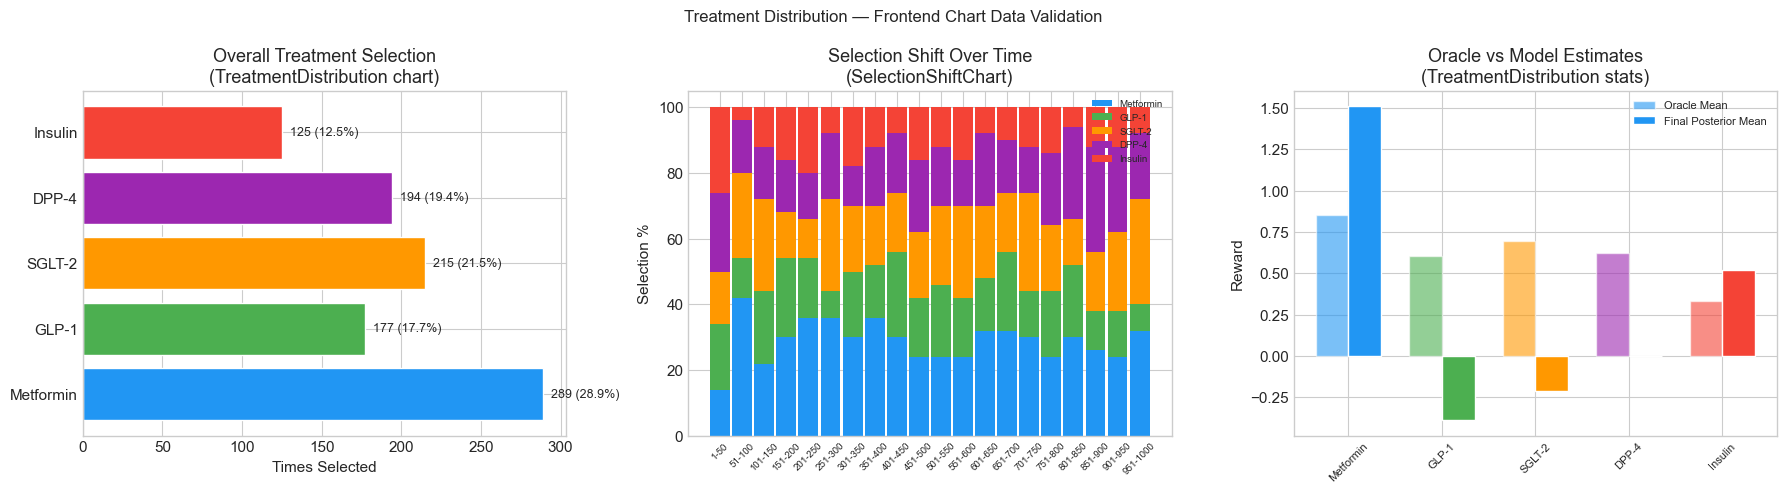

In [8]:
## Recreates the TreatmentDistribution + SelectionShiftChart
## from the frontend, using our extracted data.

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# --- 7a: Overall treatment selection distribution ---
ax = axes[0]
counts = steps_df["selected"].value_counts()
colors = [TREATMENT_COLORS[t] for t in TREATMENTS]
vals = [counts.get(t, 0) for t in TREATMENTS]
bars = ax.barh(TREATMENTS, vals, color=colors, edgecolor="white")
for bar, val in zip(bars, vals):
    pct = val / N_PATIENTS * 100
    ax.text(bar.get_width() + 5, bar.get_y() + bar.get_height()/2,
            f"{val} ({pct:.1f}%)", va="center", fontsize=9)
ax.set_xlabel("Times Selected")
ax.set_title("Overall Treatment Selection\n(TreatmentDistribution chart)")

# --- 7b: Selection shift (stacked area) ---
ax = axes[1]
bucket_size = max(50, N_PATIENTS // 20)
buckets = []
for i in range(0, N_PATIENTS, bucket_size):
    chunk = steps_df.iloc[i:i+bucket_size]
    if len(chunk) < 10:
        break
    entry = {"bucket": f"{i+1}-{min(i+bucket_size, N_PATIENTS)}"}
    for t in TREATMENTS:
        entry[t] = (chunk["selected"] == t).mean() * 100
    buckets.append(entry)

bucket_df = pd.DataFrame(buckets)
bottom = np.zeros(len(bucket_df))
for t in TREATMENTS:
    ax.bar(range(len(bucket_df)), bucket_df[t], bottom=bottom,
           color=TREATMENT_COLORS[t], label=t, width=0.9)
    bottom += bucket_df[t].values
ax.set_xticks(range(len(bucket_df)))
ax.set_xticklabels(bucket_df["bucket"], rotation=45, fontsize=7)
ax.set_ylabel("Selection %")
ax.set_title("Selection Shift Over Time\n(SelectionShiftChart)")
ax.legend(fontsize=7, loc="upper right")

# --- 7c: Estimated vs Oracle reward per treatment ---
ax = axes[2]
x_pos = np.arange(N_TREATMENTS)
width = 0.35

oracle_means = [steps_df[f"oracle_{t}"].mean() for t in TREATMENTS]
posterior_means = [steps_df[f"posterior_{t}"].iloc[-1] for t in TREATMENTS]

ax.bar(x_pos - width/2, oracle_means, width, label="Oracle Mean",
       color=[TREATMENT_COLORS[t] for t in TREATMENTS], alpha=0.6, edgecolor="white")
ax.bar(x_pos + width/2, posterior_means, width, label="Final Posterior Mean",
       color=[TREATMENT_COLORS[t] for t in TREATMENTS], alpha=1.0, edgecolor="white")
ax.set_xticks(x_pos)
ax.set_xticklabels(TREATMENTS, rotation=45, fontsize=8)
ax.set_ylabel("Reward")
ax.set_title("Oracle vs Model Estimates\n(TreatmentDistribution stats)")
ax.legend(fontsize=8)

plt.suptitle("Treatment Distribution — Frontend Chart Data Validation", fontsize=12)
plt.tight_layout()
plt.savefig("../results/frontend_treatment_dist.png", dpi=150, bbox_inches='tight')
plt.show()

## Chart — Exploration Decay & Confidence Over Time

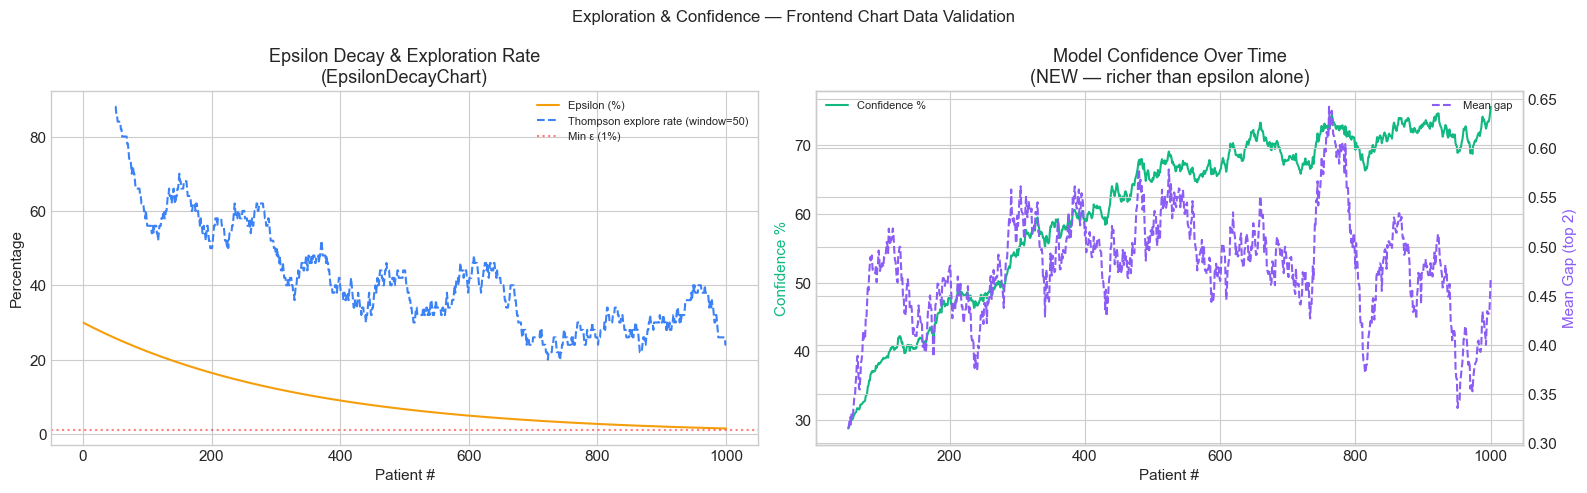

In [9]:
## Recreates EpsilonDecayChart from the frontend.
## BONUS: Also plots confidence_pct over time — richer than epsilon alone.

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# --- 8a: Epsilon decay + Thompson exploration rate ---
ax = axes[0]
window = 50
eps_vals = steps_df["epsilon"].values
thompson_explore = steps_df["thompson_explored"].rolling(window=window).mean().values * 100

ax.plot(steps_df["step"], eps_vals * 100, color="#f59e0b", linewidth=1.5, label="Epsilon (%)")
ax.plot(steps_df["step"], thompson_explore, color="#3b82f6",
        linewidth=1.5, linestyle="--", label=f"Thompson explore rate (window={window})")
ax.axhline(MIN_EPSILON * 100, color="red", linestyle=":", alpha=0.5, label=f"Min ε ({MIN_EPSILON*100:.0f}%)")
ax.set_xlabel("Patient #")
ax.set_ylabel("Percentage")
ax.set_title("Epsilon Decay & Exploration Rate\n(EpsilonDecayChart)")
ax.legend(fontsize=8)

# --- 8b: Model confidence over time ---
ax = axes[1]
confidence_vals = steps_df["confidence_pct"].rolling(window=window).mean().values
mean_gap_vals = steps_df["mean_gap"].rolling(window=window).mean().values

ax2 = ax.twinx()
ax.plot(steps_df["step"], confidence_vals, color="#10b981", linewidth=1.5, label="Confidence %")
ax2.plot(steps_df["step"], mean_gap_vals, color="#8b5cf6", linewidth=1.5, linestyle="--", label="Mean gap")

ax.set_xlabel("Patient #")
ax.set_ylabel("Confidence %", color="#10b981")
ax2.set_ylabel("Mean Gap (top 2)", color="#8b5cf6")
ax.set_title("Model Confidence Over Time\n(NEW — richer than epsilon alone)")
ax.legend(loc="upper left", fontsize=8)
ax2.legend(loc="upper right", fontsize=8)

plt.suptitle("Exploration & Confidence — Frontend Chart Data Validation", fontsize=12)
plt.tight_layout()
plt.savefig("../results/frontend_exploration.png", dpi=150, bbox_inches='tight')
plt.show()

## Chart — Regret & Accuracy Curves

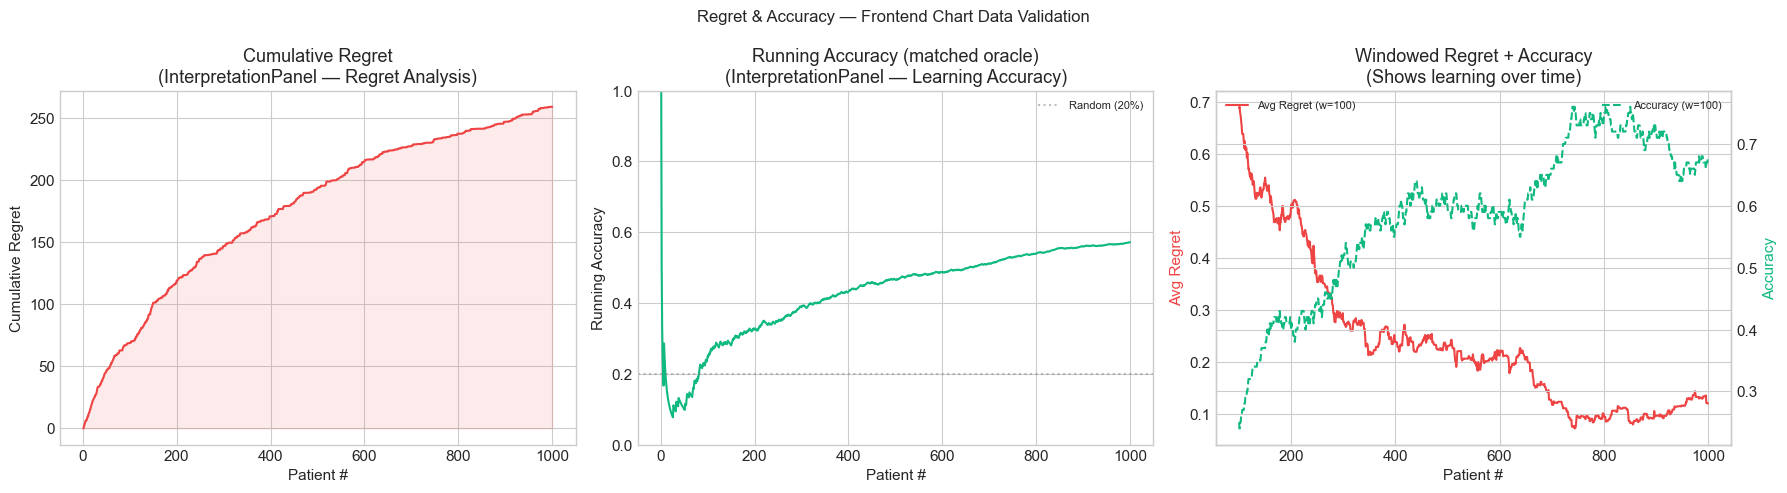

In [10]:
## Recreates the InterpretationPanel metrics.

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# --- 9a: Cumulative regret ---
ax = axes[0]
ax.plot(steps_df["step"], steps_df["cumulative_regret"], color="#ef4444", linewidth=1.5)
ax.set_xlabel("Patient #")
ax.set_ylabel("Cumulative Regret")
ax.set_title("Cumulative Regret\n(InterpretationPanel — Regret Analysis)")
ax.fill_between(steps_df["step"], steps_df["cumulative_regret"], alpha=0.1, color="#ef4444")

# --- 9b: Running accuracy ---
ax = axes[1]
ax.plot(steps_df["step"], steps_df["running_accuracy"], color="#10b981", linewidth=1.5)
ax.set_xlabel("Patient #")
ax.set_ylabel("Running Accuracy")
ax.set_title("Running Accuracy (matched oracle)\n(InterpretationPanel — Learning Accuracy)")
ax.set_ylim(0, 1)
ax.axhline(1.0 / N_TREATMENTS, color="gray", linestyle=":", alpha=0.5, label=f"Random ({1/N_TREATMENTS:.0%})")
ax.legend(fontsize=8)

# --- 9c: Windowed regret (shows learning) ---
ax = axes[2]
window = 100
windowed_regret = steps_df["regret"].rolling(window=window).mean()
windowed_acc = steps_df["matched_oracle"].rolling(window=window).mean()

ax.plot(steps_df["step"], windowed_regret, color="#ef4444", linewidth=1.5, label=f"Avg Regret (w={window})")
ax_twin = ax.twinx()
ax_twin.plot(steps_df["step"], windowed_acc, color="#10b981", linewidth=1.5, linestyle="--", label=f"Accuracy (w={window})")
ax.set_xlabel("Patient #")
ax.set_ylabel("Avg Regret", color="#ef4444")
ax_twin.set_ylabel("Accuracy", color="#10b981")
ax.set_title("Windowed Regret + Accuracy\n(Shows learning over time)")
ax.legend(loc="upper left", fontsize=8)
ax_twin.legend(loc="upper right", fontsize=8)

plt.suptitle("Regret & Accuracy — Frontend Chart Data Validation", fontsize=12)
plt.tight_layout()
plt.savefig("../results/frontend_regret_accuracy.png", dpi=150, bbox_inches='tight')
plt.show()

## Export Sample as JSON — Frontend Preview

In [11]:
## Export a subset of the step-by-step data as JSON
## to verify the exact shape the frontend will receive.

# Export first 5 steps as a readable sample
sample_steps = all_steps[:5]

print("=" * 60)
print("JSON PAYLOAD SAMPLE — First 5 Steps")
print("=" * 60)
print(json.dumps(sample_steps[0], indent=2))

# Export full simulation as compact JSON
export_data = {
    "metadata": {
        "n_patients": N_PATIENTS,
        "initial_epsilon": INITIAL_EPSILON,
        "epsilon_decay": EPSILON_DECAY,
        "min_epsilon": MIN_EPSILON,
        "treatments": TREATMENTS,
        "treatment_colors": TREATMENT_COLORS,
        "model": "NeuralThompson",
        "noise_variance": 0.25,
    },
    "steps": all_steps,
    "aggregates": {
        "final_accuracy": round(steps_df["running_accuracy"].iloc[-1], 4),
        "final_cumulative_reward": round(steps_df["cumulative_reward"].iloc[-1], 4),
        "final_cumulative_regret": round(steps_df["cumulative_regret"].iloc[-1], 4),
        "mean_regret": round(steps_df["regret"].mean(), 4),
        "mean_reward": round(steps_df["observed_reward"].mean(), 4),
        "thompson_exploration_rate": round(steps_df["thompson_explored"].mean(), 4),
        "treatment_counts": {
            t: int((steps_df["selected"] == t).sum()) for t in TREATMENTS
        },
        "confidence_distribution": steps_df["confidence_label"].value_counts().to_dict(),
        "safety_distribution": steps_df["safety_status"].value_counts().to_dict(),
    },
}

output_path = "../results/frontend_simulation_data.json"
with open(output_path, "w") as f:
    json.dump(export_data, f, indent=2)

file_size_mb = os.path.getsize(output_path) / (1024 * 1024) if 'os' in dir() else 0
print(f"\nExported to {output_path}")
print(f"Total steps: {len(all_steps)}")

# Summary of what the frontend gets per step
print("\n" + "=" * 60)
print("PER-STEP PAYLOAD STRUCTURE")
print("=" * 60)

def print_structure(d, indent=0):
    for key, val in d.items():
        prefix = "  " * indent
        if isinstance(val, dict):
            print(f"{prefix}{key}:")
            print_structure(val, indent + 1)
        else:
            val_type = type(val).__name__
            val_preview = str(val)[:60]
            print(f"{prefix}{key}: {val_type} = {val_preview}")

print_structure(all_steps[0])

print("\n" + "=" * 60)
print("FRONTEND DATA EXTRACTION COMPLETE")
print("=" * 60)
print(f"  Steps collected:     {len(all_steps)}")
print(f"  Fields per step:     {len(all_steps[0])} top-level")
print(f"  Patient features:    {len(all_steps[0]['patient'])}")
print(f"  Oracle values:       {len(all_steps[0]['oracle'])}")
print(f"  Decision values:     {len(all_steps[0]['decision'])}")
print(f"  Exploration values:  {len(all_steps[0]['exploration'])}")
print(f"  Outcome values:      {len(all_steps[0]['outcome'])}")
print(f"  Safety values:       {len(all_steps[0]['safety'])}")
print()
print("  All charts validated against extracted data ✓")
print("  JSON export ready for frontend consumption ✓")

JSON PAYLOAD SAMPLE — First 5 Steps
{
  "step": 1,
  "epsilon": 0.2991,
  "patient": {
    "age": 63,
    "bmi": 36.8,
    "hba1c_baseline": 7.49,
    "egfr": 92.6,
    "diabetes_duration": 2.6,
    "fasting_glucose": 171.2,
    "c_peptide": 1.93,
    "cvd": 1,
    "ckd": 0,
    "nafld": 0,
    "hypertension": 1,
    "bp_systolic": 130.6,
    "ldl": 95.9,
    "hdl": 28.0,
    "triglycerides": 193.4,
    "alt": 10.0
  },
  "oracle": {
    "rewards": {
      "Metformin": 1.1434,
      "GLP-1": 0.8934,
      "SGLT-2": 1.5934,
      "DPP-4": 0.7184,
      "Insulin": 0.0
    },
    "optimal_treatment": "SGLT-2",
    "optimal_idx": 2,
    "optimal_reward": 1.5934
  },
  "decision": {
    "selected_treatment": "SGLT-2",
    "selected_idx": 2,
    "sampled_values": {
      "Metformin": 1.9116,
      "GLP-1": -2.5661,
      "SGLT-2": 2.0037,
      "DPP-4": 0.3713,
      "Insulin": -2.576
    },
    "posterior_means": {
      "Metformin": 0.0,
      "GLP-1": 0.0,
      "SGLT-2": 0.0,
      "DPP-